<Figure size 1500x600 with 0 Axes>

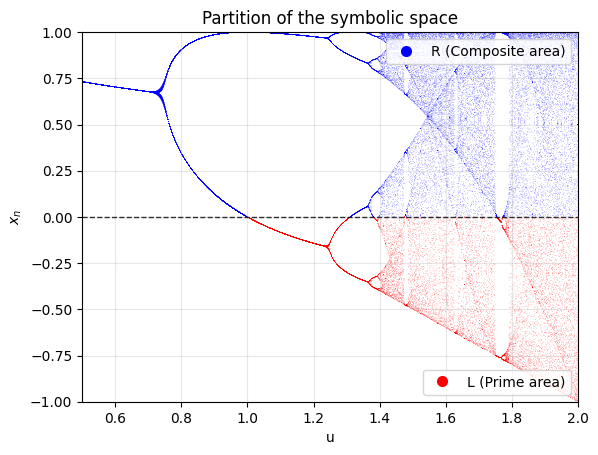

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Logistic mapping: x_{n+1} = 1 - u * x_n^2
def logistic_map(x, u):
    return 1 - u * x**2

# Parameter settings
u_min = 0.5
u_max = 2.0
u_steps = 1000
x_init = 0.5  # Initial value
transient = 100  # Burn-in: discard first 100 points to reach steady state
num_points = 100  # Number of points recorded per u

# Generate u values
u_values = np.linspace(u_min, u_max, u_steps)

# Storage
x_data = []
u_data = []

# Generate bifurcation data
for u in u_values:
    x = x_init
    for _ in range(transient):
        x = logistic_map(x, u)
    for _ in range(num_points):
        x = logistic_map(x, u)
        x_data.append(x)
        u_data.append(u)

# Plot bifurcation diagram
plt.figure(figsize=(15, 6))

# Separate positive and negative values
positive_x = [x for x, u in zip(x_data, u_data) if x > 0]
negative_x = [x for x, u in zip(x_data, u_data) if x <= 0]
positive_u = [u for x, u in zip(x_data, u_data) if x > 0]
negative_u = [u for x, u in zip(x_data, u_data) if x <= 0]

import matplotlib.pyplot as plt

# Assumes negative_u, negative_x, positive_u, positive_x, u_min, u_max are defined
# Scatter plot
fig, ax = plt.subplots()
ax.scatter(positive_u, positive_x, s=0.1, c='blue', edgecolors='none', label='R')
ax.scatter(negative_u, negative_x, s=0.1, c='red', edgecolors='none', label='L')

# Axis labels and title
ax.set_xlabel('u')
ax.set_ylabel('$x_n$')
ax.set_title('Partition of the symbolic space')
ax.set_xlim(u_min, u_max)
ax.set_ylim(-1, 1)
ax.grid(True, alpha=0.3)

# Create two separate legends
from matplotlib.lines import Line2D

# Horizontal reference line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

# Custom legend entry for positive (R) region
positive_legend = Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='R (Composite area)', markeredgecolor='none')
# Custom legend entry for negative (L) region
negative_legend = Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='L (Prime area)', markeredgecolor='none')


# Add the two legends at the specified locations
first_legend = plt.legend(handles=[positive_legend], loc='upper right')
ax.add_artist(first_legend) # Important: otherwise the first legend would be overwritten by the second
plt.legend(handles=[negative_legend], loc='lower right')

plt.show()